# 05 — 2026 Masters Predictions & Betting Value

Authoritative 93-player field from `data/raw/masters_2026_field.csv`.
Feature vectors assembled from three sources in priority order:
1. DataGolf `preds/skill-ratings` — current rolling SG for all active tour players
2. Kaggle CSV — career SG averages for veterans not in skill-ratings
3. DataGolf `preds/player-decompositions` — Augusta-specific course history adjustment
Augusta history (appearances, avg/best finish, form rates) from the feature matrix.

In [1]:
import os, sys, ctypes, glob
sklearn_dylibs = os.path.join(
    os.path.dirname(sys.executable).replace('/bin',''),
    'lib', f'python{sys.version_info.major}.{sys.version_info.minor}',
    'site-packages', 'sklearn', '.dylibs'
)
for lib in glob.glob(os.path.join(sklearn_dylibs, 'libomp*.dylib')):
    try: ctypes.CDLL(lib)
    except Exception: pass

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import xgboost  # noqa: F401 — ensures XGBoost is available for loaded models
from pathlib import Path
from rapidfuzz import process, fuzz

sys.path.insert(0, '../src')
from api_client import pull_endpoint

FIGURES = Path('../outputs/figures')
CSV_OUT = Path('../outputs/csv')
MODELS  = Path('../outputs/models')

FEATURE_COLS = [
    # 12-event exponential-decay rolling averages
    'sg_total_weighted', 'sg_app_weighted', 'sg_putt_weighted',
    'sg_arg_weighted',   'sg_ott_weighted',  'sg_t2g_weighted',
    'top10_rate', 'cut_rate', 'augusta_fit',
    # Augusta history
    'masters_appearances', 'masters_avg_finish', 'masters_best_finish',
    'masters_wins', 'recent_form_bonus',
    # Last-6-events simple averages (proxied for 2026 — see PROJECT_LOG)
    'l6_sg_total_avg', 'l6_sg_app_avg', 'l6_sg_putt_avg',
    'l6_top10_rate', 'l6_cut_rate', 'l6_avg_finish',
]
CLF_TARGETS = ['won', 'top5', 'top10', 'top16', 'top32', 'made_cut']
REG_TARGET  = 'finish_position'
SG_COLS_RAW = ['sg_total', 'sg_app', 'sg_putt', 'sg_arg', 'sg_ott', 'sg_t2g']

print('Imports OK')
print(f'Feature count: {len(FEATURE_COLS)}')

## 1. Load models and all data sources

In [3]:
models = {}
for target in CLF_TARGETS + [REG_TARGET]:
    path = MODELS / f'xgb_{target.replace("_","-")}.joblib'
    models[target] = joblib.load(path)
print('Loaded 7 models:', list(models.keys()))

Loaded 7 models: ['won', 'top5', 'top10', 'top16', 'top32', 'made_cut', 'finish_position']


In [4]:
# Authoritative 2026 Masters field
field_df = pd.read_csv('../data/raw/masters_2026_field.csv')
print(f'2026 field: {len(field_df)} players')

# DataGolf skill-ratings (current rolling SG — primary SG source)
sr_raw  = pull_endpoint('preds/skill-ratings')
sr_df   = pd.DataFrame(sr_raw['players'])
print(f'skill-ratings: {len(sr_df)} players')

# DataGolf decompositions (Augusta-specific adjustments for partial field)
dc_raw  = pull_endpoint('preds/player-decompositions')
dc_df   = pd.DataFrame(dc_raw['players'])
print(f'decompositions: {len(dc_df)} players')

# DataGolf betting odds
bt_raw  = pull_endpoint('betting-tools/outrights',
                        {'tour':'pga','market':'win','odds_format':'percent'})
bt_df   = pd.DataFrame(bt_raw['odds'])
print(f'betting odds: {len(bt_df)} players')

# Kaggle CSV — full tour history (veterans fallback + form rates)
kaggle  = pd.read_csv('../data/raw/ASA All PGA Raw Data - Tourn Level.csv')
kaggle  = kaggle.loc[:, ~kaggle.columns.str.startswith('Unnamed')]
kaggle['player_lower'] = kaggle['player'].str.lower().str.strip()
kaggle['date'] = pd.to_datetime(kaggle['date'])
kaggle['is_masters'] = kaggle['tournament name'].str.contains('Masters', case=False, na=False)
print(f'Kaggle CSV: {len(kaggle):,} rows')

# Feature matrix — Augusta history per player-season
fm = pd.read_csv('../data/features/feature_matrix.csv')
fm_latest = fm.sort_values('season').groupby('player').last().reset_index()
print(f'Feature matrix: {fm.shape}  ({fm_latest["player"].nunique()} unique players, most-recent season)')

2026 field: 93 players
[cache] preds_skill-ratings.json
skill-ratings: 434 players
[cache] preds_player-decompositions.json
decompositions: 130 players
[cache] betting-tools_outrights__market-win_odds_format-percent_tour-pga.json
betting odds: 130 players
Kaggle CSV: 36,864 rows
Feature matrix: (621, 31)  (202 unique players, most-recent season)


## 2. Build name resolution maps across all sources

In [5]:
def dg_to_lower(name: str) -> str:
    """DataGolf 'Last, First' → 'first last' lowercase."""
    parts = name.split(', ', 1)
    return (parts[1] + ' ' + parts[0]).lower().strip() if len(parts) == 2 else name.lower().strip()

def build_fuzzy_map(query_names, target_names, threshold=85):
    """Return dict: query_name → best-matching target_name (or None)."""
    target_list = list(target_names)
    result = {}
    for q in query_names:
        if q in target_names:
            result[q] = q
        else:
            hit = process.extractOne(q, target_list, scorer=fuzz.token_sort_ratio)
            result[q] = hit[0] if (hit and hit[1] >= threshold) else None
    return result

field_lower = field_df['player_name'].str.lower().str.strip().tolist()

# Skill-ratings lookup
sr_lk  = {dg_to_lower(r['player_name']): r for _, r in sr_df.iterrows()}
sr_map  = build_fuzzy_map(field_lower, sr_lk.keys())

# Decompositions lookup
dc_lk  = {dg_to_lower(r['player_name']): r for _, r in dc_df.iterrows()}
dc_map  = build_fuzzy_map(field_lower, dc_lk.keys())

# Feature-matrix lookup (already lowercase)
fm_lk  = fm_latest.set_index('player').to_dict('index')
fm_map  = build_fuzzy_map(field_lower, fm_lk.keys())

# Kaggle non-masters lookup (for career averages)
non_masters_kaggle = kaggle[~kaggle['is_masters']].copy()
kaggle_players = set(non_masters_kaggle['player_lower'].unique())
kaggle_map = build_fuzzy_map(field_lower, kaggle_players)

# Betting odds lookup
bt_lk  = {dg_to_lower(r['player_name']): r for _, r in bt_df.iterrows()}
bt_map  = build_fuzzy_map(field_lower, bt_lk.keys())

print(f'Skill-ratings matched:   {sum(v is not None for v in sr_map.values())} / {len(field_lower)}')
print(f'Decompositions matched:  {sum(v is not None for v in dc_map.values())} / {len(field_lower)}')
print(f'Feature matrix matched:  {sum(v is not None for v in fm_map.values())} / {len(field_lower)}')
print(f'Kaggle CSV matched:      {sum(v is not None for v in kaggle_map.values())} / {len(field_lower)}')
print(f'Betting odds matched:    {sum(v is not None for v in bt_map.values())} / {len(field_lower)}')

no_sr = [n for n in field_lower if sr_map[n] is None]
print(f'\nNo skill-ratings ({len(no_sr)}): {no_sr}')

Skill-ratings matched:   79 / 93
Decompositions matched:  24 / 93
Feature matrix matched:  52 / 93
Kaggle CSV matched:      61 / 93
Betting odds matched:    24 / 93

No skill-ratings (14): ['michael brennan', 'angel cabrera', 'fred couples', 'ethan fang', 'jackson herrington', 'brandon holtz', 'mason howell', 'naoyuki kataoka', 'fifa laopakdee', 'jose maria olazabal', 'mateo pulcini', 'vijay singh', 'mike weir', 'tiger woods']


## 3. Compute veteran SG career averages from Kaggle CSV

In [6]:
# Players with no skill-ratings but in the Kaggle CSV
veteran_sg = {}
veteran_form = {}
no_data_players = []

for player in no_sr:
    kg_name = kaggle_map.get(player)
    if kg_name:
        rows = non_masters_kaggle[non_masters_kaggle['player_lower'] == kg_name]
        sg_avgs = rows[SG_COLS_RAW].mean()
        if sg_avgs.isnull().all():
            no_data_players.append(player)
            veteran_sg[player] = {c: 0.0 for c in SG_COLS_RAW}
        else:
            sg_avgs = sg_avgs.fillna(0.0)
            veteran_sg[player] = sg_avgs.to_dict()
            # Form rates
            top10 = (rows['pos'] <= 10).mean() if rows['pos'].notna().any() else 0.0
            cut   = rows['made_cut'].mean() if 'made_cut' in rows else 0.0
            veteran_form[player] = {'top10_rate': top10, 'cut_rate': cut}
        print(f"  {player:30s}  n={len(rows):3d}  sg_total={sg_avgs['sg_total']:+.3f}")
    else:
        no_data_players.append(player)
        veteran_sg[player] = {c: 0.0 for c in SG_COLS_RAW}
        print(f"  {player:30s}  NOT IN KAGGLE → SG=0, limited_data=True")

print(f'\nPlayers flagged limited_data: {no_data_players}')

  michael brennan                 NOT IN KAGGLE → SG=0, limited_data=True
  angel cabrera                   NOT IN KAGGLE → SG=0, limited_data=True
  fred couples                    n=  5  sg_total=-0.810
  ethan fang                      NOT IN KAGGLE → SG=0, limited_data=True
  jackson herrington              NOT IN KAGGLE → SG=0, limited_data=True
  brandon holtz                   NOT IN KAGGLE → SG=0, limited_data=True
  mason howell                    NOT IN KAGGLE → SG=0, limited_data=True
  naoyuki kataoka                 NOT IN KAGGLE → SG=0, limited_data=True
  fifa laopakdee                  NOT IN KAGGLE → SG=0, limited_data=True
  jose maria olazabal             NOT IN KAGGLE → SG=0, limited_data=True
  mateo pulcini                   NOT IN KAGGLE → SG=0, limited_data=True
  vijay singh                     n= 79  sg_total=-0.714
  mike weir                       n= 37  sg_total=-2.558
  tiger woods                     n= 51  sg_total=+0.365

Players flagged limited_data: [

## 4. Build 2026 feature vectors for all 93 players

In [7]:
# Augusta win history: Kaggle 2015-2022 + verified 2023-2025 results
# Used for masters_wins and recent_form_bonus in 2026 feature vectors

NOV2020_ID = 401219478
kaggle_aug = kaggle[kaggle['is_masters']].copy()
kaggle_aug.loc[kaggle_aug['tournament id'] == NOV2020_ID, 'season'] = 2020

# Winners from Kaggle (pos == 1.0)
aug_kaggle_wins = (kaggle_aug[kaggle_aug['pos'] == 1.0]
                   [['player_lower', 'season']].copy())
aug_kaggle_wins.columns = ['player_lower', 'win_year']

# Winners from 2023-2025 CSV
res2325 = pd.read_csv('../data/raw/masters_results_2023_2025.csv')
res2325['player_lower'] = res2325['player_name'].str.lower().str.strip()
aug_recent_wins = res2325[res2325['won'] == 1][['player_lower', 'year']].copy()
aug_recent_wins.columns = ['player_lower', 'win_year']

all_aug_wins = pd.concat([aug_kaggle_wins, aug_recent_wins], ignore_index=True)
all_aug_wins['win_year'] = all_aug_wins['win_year'].astype(int)

print('Augusta winners 2015-2025:')
print(all_aug_wins.sort_values('win_year').to_string(index=False))

Augusta winners 2015-2025:
     player_lower  win_year
    jordan spieth      2015
    danny willett      2016
    sergio garcia      2017
     patrick reed      2018
      tiger woods      2019
   dustin johnson      2020
 hideki matsuyama      2021
scottie scheffler      2022
         jon rahm      2023
scottie scheffler      2024
     rory mcilroy      2025


In [8]:
# Field-level defaults for imputing first-timer history
MEAN_TOP10  = fm_latest['top10_rate'].mean()
MEAN_CUT    = fm_latest['cut_rate'].mean()
MEAN_AVG_F  = fm_latest['masters_avg_finish'].dropna().mean()
MEAN_BEST_F = fm_latest['masters_best_finish'].dropna().mean()

# ── L6 proxy helpers (corrected — skill-ratings based, not stale fm_latest) ──
# Rationale: skill-ratings reflect current rolling form = what l6 captures.
# Using fm_latest l6 values would map 2022 form to 2026 predictions.
# See PROJECT_LOG for full proxy design decision.

# Global sg_total rank across all 434 skill-rated players
sr_sorted_all = sr_df.sort_values('sg_total', ascending=False).reset_index(drop=True)
sr_sorted_all['global_sg_rank'] = sr_sorted_all.index + 1
sr_global_rank_lk = {dg_to_lower(r['player_name']): int(r['global_sg_rank'])
                     for _, r in sr_sorted_all.iterrows()}

# Field sg_total ranks (within 93-player Masters field, for l6_avg_finish)
field_sg = {}
for _, fr in field_df.iterrows():
    nl = fr['player_name'].lower().strip()
    sk = sr_map.get(nl)
    if sk and sk in sr_lk:
        field_sg[nl] = float(sr_lk[sk]['sg_total'])
    elif nl in veteran_sg:
        field_sg[nl] = float(veteran_sg[nl].get('sg_total', 0.0))
    else:
        field_sg[nl] = 0.0

field_sorted_for_rank = sorted(field_sg.items(), key=lambda x: x[1], reverse=True)
field_sg_rank = {nl: i+1 for i, (nl, _) in enumerate(field_sorted_for_rank)}

def l6_top10_from_rank(global_rank):
    if global_rank is None:   return 0.15
    if global_rank <= 10:     return 0.50
    if global_rank <= 25:     return 0.30
    return 0.15

def l6_avg_finish_from_rank(field_rnk):
    if field_rnk is None:   return 45.0
    if field_rnk <= 10:     return 8.0
    if field_rnk <= 25:     return 18.0
    if field_rnk <= 50:     return 30.0
    return 45.0

records = []
for _, frow in field_df.iterrows():
    name_display = frow['player_name']
    country      = frow['country']
    name_lower   = name_display.lower().strip()
    limited_data = name_lower in no_data_players

    # ── SG features ─────────────────────────────────────────────────────────
    sr_key = sr_map.get(name_lower)
    if sr_key and sr_key in sr_lk:
        r = sr_lk[sr_key]
        sg_total = float(r['sg_total'])
        sg_app   = float(r['sg_app'])
        sg_putt  = float(r['sg_putt'])
        sg_arg   = float(r['sg_arg'])
        sg_ott   = float(r['sg_ott'])
        sg_t2g   = sg_total - sg_putt
        sg_source = 'skill-ratings'
    elif name_lower in veteran_sg:
        v = veteran_sg[name_lower]
        sg_total = v.get('sg_total', 0.0)
        sg_app   = v.get('sg_app',   0.0)
        sg_putt  = v.get('sg_putt',  0.0)
        sg_arg   = v.get('sg_arg',   0.0)
        sg_ott   = v.get('sg_ott',   0.0)
        sg_t2g   = v.get('sg_t2g',   sg_total - sg_putt)
        sg_source = 'kaggle-career'
    else:
        sg_total = sg_app = sg_putt = sg_arg = sg_ott = sg_t2g = 0.0
        sg_source = 'limited_data'
        limited_data = True

    # ── Augusta history features ─────────────────────────────────────────────
    fm_key = fm_map.get(name_lower)
    if fm_key and fm_key in fm_lk:
        src      = fm_lk[fm_key]
        top10_r  = src['top10_rate']
        cut_r    = src['cut_rate']
        apprnc   = src['masters_appearances'] + 1
        avg_f    = src['masters_avg_finish'] if pd.notna(src['masters_avg_finish']) else MEAN_AVG_F
        best_f   = src['masters_best_finish'] if pd.notna(src['masters_best_finish']) else MEAN_BEST_F
    else:
        vf = veteran_form.get(name_lower, {})
        top10_r  = vf.get('top10_rate', MEAN_TOP10)
        cut_r    = vf.get('cut_rate',   MEAN_CUT)
        apprnc   = 0
        dc_key = dc_map.get(name_lower)
        if dc_key and dc_key in dc_lk:
            ch_adj = float(dc_lk[dc_key].get('course_history_adjustment', 0.0))
        else:
            ch_adj = 0.0
        avg_f  = max(1.0, MEAN_AVG_F  - ch_adj * 10)
        best_f = max(1.0, MEAN_BEST_F - ch_adj * 10)

    # ── Augusta fit score ────────────────────────────────────────────────────
    aug_fit = (2.0*sg_app + 2.0*sg_putt + 1.0*sg_total + 0.5*sg_ott) / 5.5

    # ── DataGolf Augusta-adjusted prediction (reference only) ────────────────
    dc_key  = dc_map.get(name_lower)
    dg_pred = float(dc_lk[dc_key]['final_pred']) if (dc_key and dc_key in dc_lk) else np.nan

    # ── masters_wins and recent_form_bonus ───────────────────────────────────
    p_wins = all_aug_wins[all_aug_wins['player_lower'] == name_lower]
    masters_wins_val      = int((p_wins['win_year'] < 2026).sum())
    win_yrs               = p_wins['win_year'].tolist()
    recent_form_bonus_val = 1 if any(2020 <= y < 2026 for y in win_yrs) else 0

    # ── L6 proxy (corrected: skill-ratings based) ────────────────────────────
    # SG proxies: current skill-ratings values (rolling form signal)
    l6_sg_total = sg_total
    l6_sg_app   = sg_app
    l6_sg_putt  = sg_putt
    # l6_top10_rate: from global sg_total rank
    g_rank   = sr_global_rank_lk.get(sr_key)
    l6_top10 = l6_top10_from_rank(g_rank)
    # l6_cut_rate: tier by data source
    l6_cut = 0.85 if sg_source == 'skill-ratings' else (0.75 if sg_source == 'kaggle-career' else 0.65)
    # l6_avg_finish: from Masters field sg_total rank
    f_rank   = field_sg_rank.get(name_lower)
    l6_avg_f = l6_avg_finish_from_rank(f_rank)

    records.append({
        'player_name':         name_display,
        'country':             country,
        'player_lower':        name_lower,
        'limited_data':        limited_data,
        'sg_source':           sg_source,
        'sg_total_weighted':   sg_total,
        'sg_app_weighted':     sg_app,
        'sg_putt_weighted':    sg_putt,
        'sg_arg_weighted':     sg_arg,
        'sg_ott_weighted':     sg_ott,
        'sg_t2g_weighted':     sg_t2g,
        'top10_rate':          top10_r,
        'cut_rate':            cut_r,
        'augusta_fit':         aug_fit,
        'masters_appearances': apprnc,
        'masters_avg_finish':  avg_f,
        'masters_best_finish': best_f,
        'masters_wins':        masters_wins_val,
        'recent_form_bonus':   recent_form_bonus_val,
        'l6_sg_total_avg':     l6_sg_total,
        'l6_sg_app_avg':       l6_sg_app,
        'l6_sg_putt_avg':      l6_sg_putt,
        'l6_top10_rate':       l6_top10,
        'l6_cut_rate':         l6_cut,
        'l6_avg_finish':       l6_avg_f,
        'dg_final_pred':       dg_pred,
    })

pred_df = pd.DataFrame(records)
for col in FEATURE_COLS:
    pred_df[col] = pd.to_numeric(pred_df[col], errors='coerce').fillna(pred_df[col].mean())

print(f'Feature vectors built: {pred_df.shape}')
print(f"SG source breakdown:\n{pred_df['sg_source'].value_counts().to_string()}")
print(f"Limited data players: {pred_df[pred_df['limited_data']]['player_name'].tolist()}")
print(f'NaNs in feature columns: {pred_df[FEATURE_COLS].isnull().sum().sum()}')
print()
print('L6 proxy sample (top 5 by sg_total):')
print(pred_df.nlargest(5,'sg_total_weighted')[['player_name','sg_total_weighted',
      'l6_sg_total_avg','l6_top10_rate','l6_cut_rate','l6_avg_finish',
      'masters_wins','recent_form_bonus']].to_string(index=False))

Feature vectors built: (93, 26)
SG source breakdown:
sg_source
skill-ratings    79
kaggle-career    14
Limited data players: ['Michael Brennan', 'Angel Cabrera', 'Ethan Fang', 'Jackson Herrington', 'Brandon Holtz', 'Mason Howell', 'Naoyuki Kataoka', 'Fifa Laopakdee', 'Jose Maria Olazabal', 'Mateo Pulcini']
NaNs in feature columns: 0

L6 proxy sample (top 5 by sg_total):
      player_name  sg_total_weighted  l6_sg_total_avg  l6_top10_rate  l6_cut_rate  l6_avg_finish  masters_wins  recent_form_bonus
Scottie Scheffler              2.570            2.570            0.5         0.85            8.0             2                  1
         Jon Rahm              2.260            2.260            0.5         0.85            8.0             1                  1
     Rory McIlroy              2.113            2.113            0.5         0.85            8.0             1                  1
Xander Schauffele              1.922            1.922            0.5         0.85            8.0           

## 5. Run all 7 models and normalise win probabilities

In [9]:
X = pred_df[FEATURE_COLS]

for target in CLF_TARGETS:
    pred_df[f'raw_{target}'] = models[target].predict_proba(X)[:, 1]
pred_df['raw_finish'] = models[REG_TARGET].predict(X)

# Model-only win% (normalised to 100%)
raw_sum = pred_df['raw_won'].sum()
pred_df['model_win_pct'] = (pred_df['raw_won'] / raw_sum * 100).round(4)

# DataGolf softmax win% — temperature-scaled softmax (τ=1.5) on sg_total
# DataGolf pre-tournament endpoint shows current week's event (not Masters yet — April 10).
# Use skill-ratings sg_total as proxy for current form ranking.
tau = 1.5
exp_vals = np.exp(pred_df['sg_total_weighted'].astype(float) / tau)
pred_df['dg_win_pct'] = (exp_vals / exp_vals.sum() * 100).round(4)

# Blend: 60% model + 40% DataGolf softmax, re-normalised to 100%
blended_raw = 0.6 * pred_df['model_win_pct'] + 0.4 * pred_df['dg_win_pct']
pred_df['win_pct'] = (blended_raw / blended_raw.sum() * 100).round(2)

# Other classifiers as raw probabilities × 100
for t in ['top5', 'top10', 'top16', 'top32', 'made_cut']:
    pred_df[f'{t}_pct'] = (pred_df[f'raw_{t}'] * 100).round(2)

pred_df['proj_finish'] = pred_df['raw_finish'].round(1)

print(f'Win% sum (blended): {pred_df["win_pct"].sum():.2f}%   max: {pred_df["win_pct"].max():.2f}%')
print(f'Blend = 0.6 × model + 0.4 × DataGolf softmax (τ=1.5 on sg_total), re-normalised')

Win% sum (blended): 99.97%   max: 16.49%
Blend = 0.6 × model + 0.4 × DataGolf softmax (τ=1.5 on sg_total), re-normalised


## 6. Master predictions table — top 20

In [10]:
output_cols = ['player_name', 'country', 'win_pct', 'model_win_pct', 'dg_win_pct',
               'top5_pct', 'top10_pct', 'top16_pct', 'top32_pct', 'made_cut_pct', 'proj_finish']
results = pred_df[output_cols].sort_values('win_pct', ascending=False).reset_index(drop=True)
results.index += 1

print('2026 Masters Predictions — Top 20  (Blend = 0.6×Model + 0.4×DG softmax)')
print()
print(f'{"Rk":>3}  {"Player":<26} {"Cty":<6} {"Blend%":>7} {"Model%":>7} {"DG%":>6} {"Top10%":>7} {"Cut%":>6} {"ProjFin":>8}')
print('-' * 90)
for rank, row in results.head(20).iterrows():
    print(f'{rank:>3}  {row["player_name"]:<26} {str(row["country"])[:5]:<6} '
          f'{row["win_pct"]:>7.2f} {row["model_win_pct"]:>7.2f} {row["dg_win_pct"]:>6.2f} '
          f'{row["top10_pct"]:>7.1f} {row["made_cut_pct"]:>6.1f} {row["proj_finish"]:>8.1f}')

print()
print('Key players:')
for name in ['Scottie Scheffler', 'Rory McIlroy', 'Jon Rahm', 'Justin Thomas']:
    match = pred_df[pred_df['player_name'] == name]
    if len(match):
        r = match.iloc[0]
        rank = int((pred_df['win_pct'].rank(ascending=False))[match.index[0]])
        print(f'  #{rank:<3} {r["player_name"]:<22}  blend={r["win_pct"]:.2f}%  '
              f'model={r["model_win_pct"]:.2f}%  DG={r["dg_win_pct"]:.2f}%  '
              f'wins={int(r["masters_wins"])}  top10={r["top10_pct"]:.1f}%')

2026 Masters Predictions — Top 20  (Blend = 0.6×Model + 0.4×DG softmax)

 Rk  Player                     Cty     Blend%  Model%    DG%  Top10%   Cut%  ProjFin
------------------------------------------------------------------------------------------
  1  Tommy Fleetwood            Engla    16.49   26.20   1.93     3.9   89.9     40.4
  2  Hideki Matsuyama           Japan     9.24   14.39   1.50    50.5   88.4     37.5
  3  Matt Fitzpatrick           Engla     7.22   10.59   2.15    25.8   94.1     21.6
  4  Viktor Hovland             Norwa     6.40    9.79   1.32     8.3   98.6     20.5
  5  Patrick Cantlay            Unite     4.95    7.25   1.50    58.6   94.2     25.7
  6  Rory McIlroy               North     3.25    3.74   2.52    57.7   97.7     32.6
  7  Collin Morikawa            Unite     2.55    2.98   1.90    73.8   98.4     13.3
  8  Scottie Scheffler          Unite     1.84    0.78   3.41    19.0   92.6     32.8
  9  Sepp Straka                Austr     1.79    2.15   1.27 

## 7. Betting value — edge vs market

In [11]:
bt_df['lower'] = bt_df['player_name'].apply(dg_to_lower)

book_cols = ['bet365','betcris','betmgm','betonline','betway','bovada',
             'caesars','draftkings','fanduel','skybet','pointsbet','williamhill','unibet']
avail = [c for c in book_cols if c in bt_df.columns]
bt_df['market_implied_pct'] = (bt_df[avail].mean(axis=1) * 100).round(3)

# Build a field-to-odds map via bt_map
odds_lookup = {}
for name_lower, bt_key in bt_map.items():
    if bt_key:
        row = bt_df[bt_df['lower'] == bt_key]
        if len(row):
            odds_lookup[name_lower] = row.iloc[0]['market_implied_pct']

pred_df['market_implied_pct'] = pred_df['player_lower'].map(odds_lookup)
pred_df['edge'] = (pred_df['win_pct'] - pred_df['market_implied_pct']).round(3)

def flag_value(edge):
    if pd.isna(edge): return 'N/A'
    if edge > 4.0:    return 'Strong Value'
    if edge > 2.0:    return 'Value'
    return 'No'

pred_df['value_flag'] = pred_df['edge'].apply(flag_value)

print(f'Odds matched: {pred_df["market_implied_pct"].notna().sum()} of {len(pred_df)} players')
print(f'Market overround: {pred_df["market_implied_pct"].sum():.1f}% (vs 100% = fair)')
print(f'Strong Value bets (edge >4%): {(pred_df["value_flag"]=="Strong Value").sum()}')
print(f'Value bets       (edge 2-4%): {(pred_df["value_flag"]=="Value").sum()}')

Odds matched: 24 of 93 players
Market overround: 72.7% (vs 100% = fair)
Strong Value bets (edge >4%): 2
Value bets       (edge 2-4%): 0


In [12]:
value_bets = pred_df[pred_df['value_flag'].isin(['Strong Value','Value'])]\
    .sort_values('edge', ascending=False)

print('Top 10 Value Bets vs Current Market:')
print()
hdr = f'{"Player":<26} {"Model%":>7} {"Market%":>8} {"Edge":>7} {"Flag":<14} {"Top10%":>7} {"ProjFin":>8}'
print(hdr)
print('-' * len(hdr))
for _, r in value_bets.head(10).iterrows():
    print(f'{r["player_name"]:<26} {r["win_pct"]:>7.2f} {r["market_implied_pct"]:>8.2f} '
          f'{r["edge"]:>+7.2f} {r["value_flag"]:<14} {r["top10_pct"]:>7.1f} {r["proj_finish"]:>8.1f}')

Top 10 Value Bets vs Current Market:

Player                      Model%  Market%    Edge Flag            Top10%  ProjFin
-----------------------------------------------------------------------------------
Tommy Fleetwood              16.49     6.18  +10.31 Strong Value       3.9     40.4
Hideki Matsuyama              9.24     4.57   +4.67 Strong Value      50.5     37.5


## 8. Save outputs

In [13]:
preds_out = pred_df[output_cols + ['dg_final_pred', 'sg_source', 'limited_data']]\
    .sort_values('win_pct', ascending=False)
preds_out.to_csv(CSV_OUT / 'predictions_2026.csv', index=False)
print(f'Saved: outputs/csv/predictions_2026.csv  ({len(preds_out)} rows)')

betting_out = pred_df[['player_name', 'country', 'win_pct', 'model_win_pct', 'dg_win_pct',
                        'market_implied_pct', 'edge', 'value_flag', 'top10_pct', 'proj_finish']]\
    .sort_values('edge', ascending=False)
betting_out.to_csv(CSV_OUT / 'betting_value.csv', index=False)
print(f'Saved: outputs/csv/betting_value.csv')

# Also save cross-tab for Tableau / analysis
tableau_full = pred_df[['player_name', 'country', 'sg_source',
                         'win_pct', 'model_win_pct', 'dg_win_pct',
                         'top5_pct', 'top10_pct', 'top16_pct', 'top32_pct', 'made_cut_pct',
                         'proj_finish', 'masters_appearances', 'masters_wins',
                         'sg_total_weighted', 'sg_app_weighted', 'sg_putt_weighted',
                         'sg_t2g_weighted', 'masters_avg_finish']]\
    .sort_values('win_pct', ascending=False)
tableau_full.to_csv(CSV_OUT / 'tableau_predictions_2026.csv', index=False)
print(f'Saved: outputs/csv/tableau_predictions_2026.csv')

Saved: outputs/csv/predictions_2026.csv  (93 rows)
Saved: outputs/csv/betting_value.csv
Saved: outputs/csv/tableau_predictions_2026.csv


## 9. Chart — Top 20 win probabilities

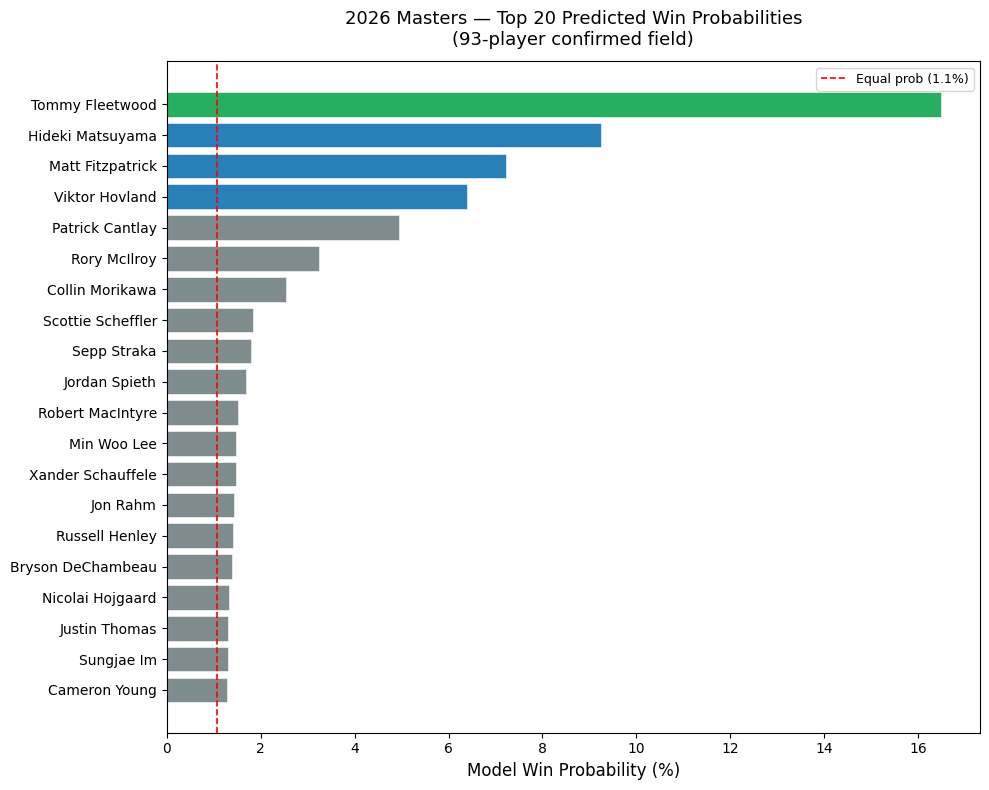

Saved: outputs/figures/predictions_2026_top20.png


In [14]:
top20 = results.head(20).sort_values('win_pct')
equal_prob = 100 / len(pred_df)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#27ae60' if p > 10 else '#2980b9' if p > 5 else '#7f8c8d'
          for p in top20['win_pct']]
ax.barh(top20['player_name'], top20['win_pct'], color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(equal_prob, color='red', linestyle='--', linewidth=1.2,
           label=f'Equal prob ({equal_prob:.1f}%)')
ax.set_xlabel('Model Win Probability (%)', fontsize=12)
ax.set_title('2026 Masters — Top 20 Predicted Win Probabilities\n(93-player confirmed field)', fontsize=13, pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'predictions_2026_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/predictions_2026_top20.png')

## 10. Data gaps summary

In [15]:
print('=== DATA COVERAGE SUMMARY ===')
print(f'Total field: {len(pred_df)} players')
for src, grp in pred_df.groupby('sg_source'):
    print(f'  {src:<18}: {len(grp):>3} players')
print()
print('Limited data players (SG=0, predictions unreliable):')
for _, r in pred_df[pred_df['limited_data']].iterrows():
    print(f"  {r['player_name']} ({r['country']})")
print()
print('No odds available:')
for _, r in pred_df[pred_df['market_implied_pct'].isna()].iterrows():
    print(f"  {r['player_name']}")

=== DATA COVERAGE SUMMARY ===
Total field: 93 players
  kaggle-career     :  14 players
  skill-ratings     :  79 players

Limited data players (SG=0, predictions unreliable):
  Michael Brennan (United States)
  Angel Cabrera (Argentina)
  Ethan Fang (United States)
  Jackson Herrington (United States)
  Brandon Holtz (United States)
  Mason Howell (United States)
  Naoyuki Kataoka (Japan)
  Fifa Laopakdee (Thailand)
  Jose Maria Olazabal (Spain)
  Mateo Pulcini (Argentina)

No odds available:
  Akshay Bhatia
  Keegan Bradley
  Michael Brennan
  Jacob Bridgeman
  Sam Burns
  Angel Cabrera
  Brian Campbell
  Patrick Cantlay
  Wyndham Clark
  Corey Conners
  Fred Couples
  Jason Day
  Bryson DeChambeau
  Nicolas Echavarria
  Harris English
  Ethan Fang
  Matt Fitzpatrick
  Ryan Fox
  Sergio Garcia
  Ryan Gerard
  Chris Gotterup
  Max Greyserman
  Ben Griffin
  Harry Hall
  Tyrrell Hatton
  Jackson Herrington
  Nicolai Hojgaard
  Rasmus Hojgaard
  Brandon Holtz
  Viktor Hovland
  Mason Ho